In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [11]:
# frozen walkers only sample exp(T2) for the trial
data = '''
# n_mol        E[CCSD]        E[AFQMC/stoFullCCSD]         Sign                error_indep
    1       -1.09607128     -1.096117 +/- 0.000243  0.998684 + i  0.000293      0.000243
    2       -2.19214256     -2.192198 +/- 0.000398  0.997464 + i  0.001922      0.000402
    4       -4.38428513     -4.383225 +/- 0.000946  0.995221 + i  0.000009      0.000883
    8       -8.76857026     -8.769717 +/- 0.001472  0.990313 + i  0.003170      0.001472
    16      -17.5371405     -17.53351 +/- 0.003614  0.960431 + i -0.014430      0.003614
    32      -35.0742810     -35.04377 +/- 0.013704  0.963420 + i  0.019819      0.008538
'''

In [12]:
n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_sign_r = []
qmc_sign_i = []
ind_error = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_sign_r = np.hstack((qmc_sign_r,float(parts[5])/int(parts[0])))
        qmc_sign_i = np.hstack((qmc_sign_i,float(parts[8])/int(parts[0])))
        ind_error = np.hstack((ind_error,float(parts[9])/int(parts[0])))


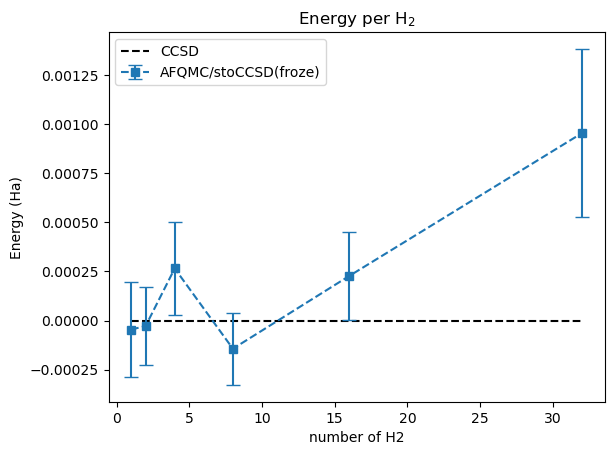

In [9]:
plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='AFQMC/stoCCSD(froze)')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

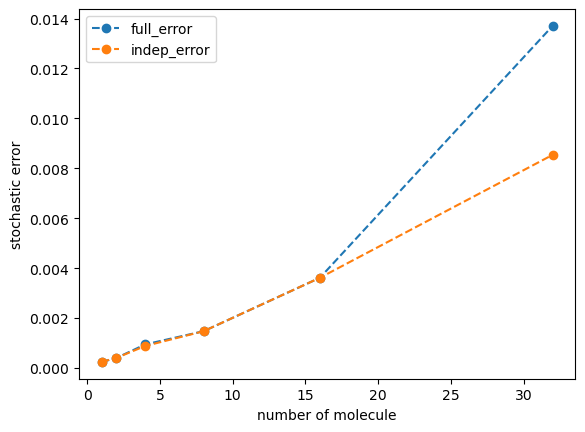

In [13]:
plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='full_error')
plt.plot(n, n*ind_error, 'o--', color='C1', label='indep_error')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

In [14]:
import numpy as np
from scipy.optimize import curve_fit

# Your error data (indexed by block_size)
errors = np.array([
    0.008538, 0.010014, 0.011178, 0.011893, 0.012530,
    0.012997, 0.013752, 0.013704, 0.014264, 0.014603,
    0.015099, 0.015119, 0.015476, 0.015709, 0.015851,
    0.015588, 0.016056, 0.016681, 0.016723, 0.016485,
    0.016832, 0.017384, 0.017322, 0.017149, 0.017754,
    0.017637, 0.017885, 0.018158, 0.018160, 0.018557,
    0.019025, 0.018119, 0.018728, 0.018576,
])
block_sizes = np.arange(1, len(errors) + 1)

# Model: error(x) = a - b * exp(-x / tau)
# 'a' is the plateau value
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau_value = popt[0]
perr = np.sqrt(np.diag(pcov))

print(f"Plateau error estimate: {plateau_value:.6f} ± {perr[0]:.6f}")
print(f"Decay constant (tau):   {popt[2]:.2f} blocks")

# Optional: find the block size where error reaches 95% of plateau
convergence_block = -popt[2] * np.log(0.05)
print(f"~95% of plateau reached at block_size ≈ {convergence_block:.0f}")

Plateau error estimate: 0.019080 ± 0.000266
Decay constant (tau):   12.26 blocks
~95% of plateau reached at block_size ≈ 37


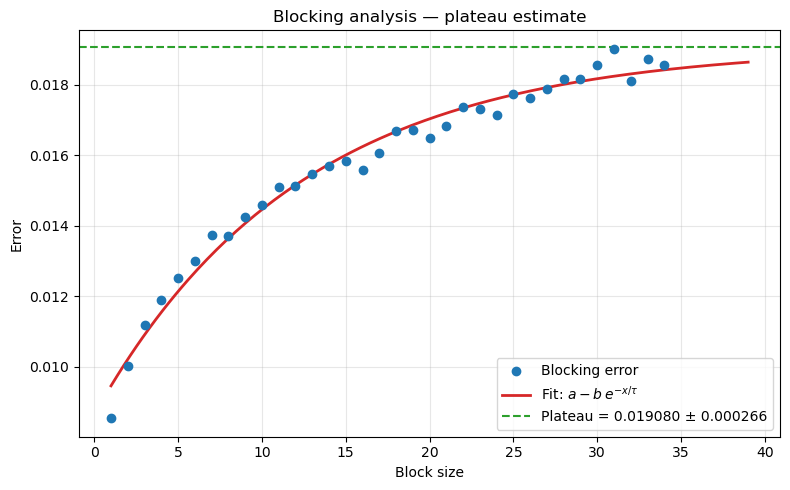

Plateau: 0.019080 ± 0.000266
tau: 12.26


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 32 H2
errors = np.array([
    0.008538, 0.010014, 0.011178, 0.011893, 0.012530,
    0.012997, 0.013752, 0.013704, 0.014264, 0.014603,
    0.015099, 0.015119, 0.015476, 0.015709, 0.015851,
    0.015588, 0.016056, 0.016681, 0.016723, 0.016485,
    0.016832, 0.017384, 0.017322, 0.017149, 0.017754,
    0.017637, 0.017885, 0.018158, 0.018160, 0.018557,
    0.019025, 0.018119, 0.018728, 0.018576,
])
block_sizes = np.arange(1, len(errors) + 1)

# Fit: error(x) = a - b * exp(-x / tau)
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau = popt[0]
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(1, block_sizes[-1] + 5, 200)
y_fit = model(x_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(block_sizes, errors, color='C0', zorder=3, label='Blocking error')
ax.plot(x_fit, y_fit, color='C3', lw=2, label=rf'Fit: $a - b\,e^{{-x/\tau}}$')
ax.axhline(plateau, color='C2', ls='--', lw=1.5,
           label=f'Plateau = {plateau:.6f} ± {perr[0]:.6f}')
ax.set_xlabel('Block size')
ax.set_ylabel('Error')
ax.set_title('Blocking analysis — plateau estimate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blocking_plateau.png', dpi=150)
plt.show()

print(f"Plateau: {plateau:.6f} ± {perr[0]:.6f}")
print(f"tau: {popt[2]:.2f}")

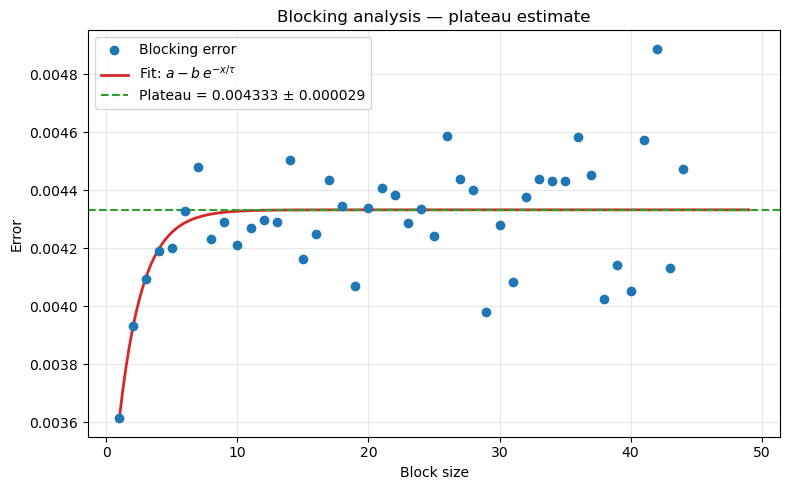

Plateau: 0.004333 ± 0.000029
tau: 1.80


In [16]:
# 16 H2
errors = np.array([
    0.003614, 0.003931, 0.004095, 0.004192, 0.004200,
    0.004327, 0.004482, 0.004232, 0.004290, 0.004213,
    0.004271, 0.004296, 0.004290, 0.004503, 0.004164,
    0.004249, 0.004436, 0.004345, 0.004069, 0.004340,
    0.004407, 0.004383, 0.004288, 0.004334, 0.004241,
    0.004586, 0.004438, 0.004401, 0.003981, 0.004279,
    0.004084, 0.004377, 0.004439, 0.004431, 0.004431,
    0.004585, 0.004453, 0.004024, 0.004142, 0.004054,
    0.004573, 0.004888, 0.004131, 0.004473,
])

block_sizes = np.arange(1, len(errors) + 1)

# Fit: error(x) = a - b * exp(-x / tau)
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau = popt[0]
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(1, block_sizes[-1] + 5, 200)
y_fit = model(x_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(block_sizes, errors, color='C0', zorder=3, label='Blocking error')
ax.plot(x_fit, y_fit, color='C3', lw=2, label=rf'Fit: $a - b\,e^{{-x/\tau}}$')
ax.axhline(plateau, color='C2', ls='--', lw=1.5,
           label=f'Plateau = {plateau:.6f} ± {perr[0]:.6f}')
ax.set_xlabel('Block size')
ax.set_ylabel('Error')
ax.set_title('Blocking analysis — plateau estimate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blocking_plateau.png', dpi=150)
plt.show()

print(f"Plateau: {plateau:.6f} ± {perr[0]:.6f}")
print(f"tau: {popt[2]:.2f}")

/tmp/ipykernel_500703/2041397988.py:24: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-x / tau)
/tmp/ipykernel_500703/2041397988.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)


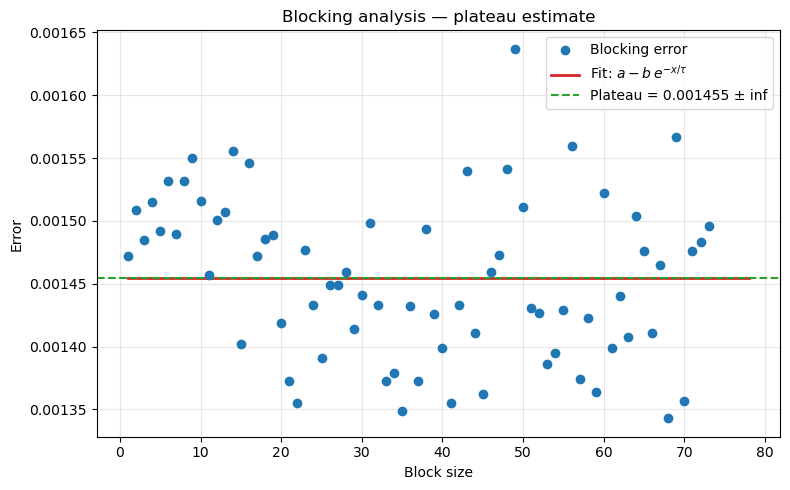

Plateau: 0.001455 ± inf
tau: 0.03


In [17]:
# 8 H2
errors = np.array([
    0.001472, 0.001509, 0.001485, 0.001515, 0.001492,
    0.001532, 0.001490, 0.001532, 0.001550, 0.001516,
    0.001457, 0.001501, 0.001507, 0.001556, 0.001402,
    0.001546, 0.001472, 0.001486, 0.001489, 0.001419,
    0.001373, 0.001355, 0.001477, 0.001433, 0.001391,
    0.001449, 0.001449, 0.001459, 0.001414, 0.001441,
    0.001498, 0.001433, 0.001373, 0.001379, 0.001349,
    0.001432, 0.001373, 0.001494, 0.001426, 0.001399,
    0.001355, 0.001433, 0.001540, 0.001411, 0.001362,
    0.001459, 0.001473, 0.001541, 0.001637, 0.001511,
    0.001431, 0.001427, 0.001386, 0.001395, 0.001429,
    0.001560, 0.001374, 0.001423, 0.001364, 0.001522,
    0.001399, 0.001440, 0.001408, 0.001504, 0.001476,
    0.001411, 0.001465, 0.001343, 0.001567, 0.001357,
    0.001476, 0.001483, 0.001496,
])

block_sizes = np.arange(1, len(errors) + 1)

# Fit: error(x) = a - b * exp(-x / tau)
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau = popt[0]
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(1, block_sizes[-1] + 5, 200)
y_fit = model(x_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(block_sizes, errors, color='C0', zorder=3, label='Blocking error')
ax.plot(x_fit, y_fit, color='C3', lw=2, label=rf'Fit: $a - b\,e^{{-x/\tau}}$')
ax.axhline(plateau, color='C2', ls='--', lw=1.5,
           label=f'Plateau = {plateau:.6f} ± {perr[0]:.6f}')
ax.set_xlabel('Block size')
ax.set_ylabel('Error')
ax.set_title('Blocking analysis — plateau estimate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blocking_plateau.png', dpi=150)
plt.show()

print(f"Plateau: {plateau:.6f} ± {perr[0]:.6f}")
print(f"tau: {popt[2]:.2f}")

/tmp/ipykernel_500703/3373898178.py:17: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-x / tau)


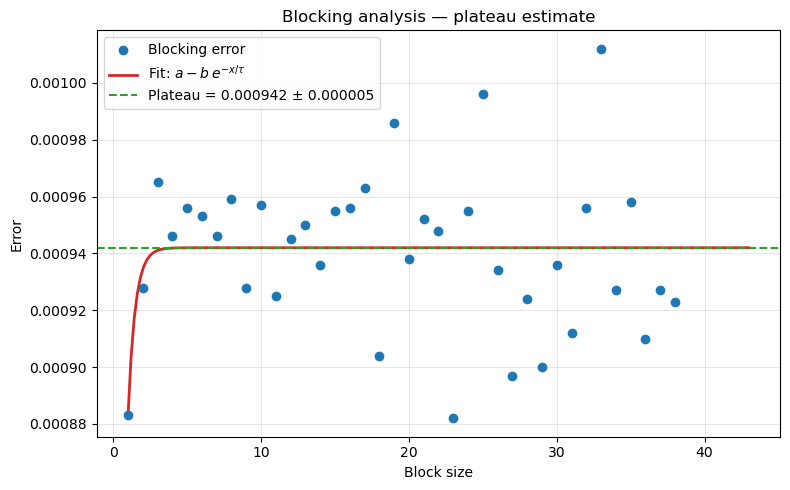

Plateau: 0.000942 ± 0.000005
tau: 0.49


In [18]:
# 4 H2
errors = np.array([
    0.000883, 0.000928, 0.000965, 0.000946, 0.000956,
    0.000953, 0.000946, 0.000959, 0.000928, 0.000957,
    0.000925, 0.000945, 0.000950, 0.000936, 0.000955,
    0.000956, 0.000963, 0.000904, 0.000986, 0.000938,
    0.000952, 0.000948, 0.000882, 0.000955, 0.000996,
    0.000934, 0.000897, 0.000924, 0.000900, 0.000936,
    0.000912, 0.000956, 0.001012, 0.000927, 0.000958,
    0.000910, 0.000927, 0.000923,
])

block_sizes = np.arange(1, len(errors) + 1)

# Fit: error(x) = a - b * exp(-x / tau)
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau = popt[0]
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(1, block_sizes[-1] + 5, 200)
y_fit = model(x_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(block_sizes, errors, color='C0', zorder=3, label='Blocking error')
ax.plot(x_fit, y_fit, color='C3', lw=2, label=rf'Fit: $a - b\,e^{{-x/\tau}}$')
ax.axhline(plateau, color='C2', ls='--', lw=1.5,
           label=f'Plateau = {plateau:.6f} ± {perr[0]:.6f}')
ax.set_xlabel('Block size')
ax.set_ylabel('Error')
ax.set_title('Blocking analysis — plateau estimate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blocking_plateau.png', dpi=150)
plt.show()

print(f"Plateau: {plateau:.6f} ± {perr[0]:.6f}")
print(f"tau: {popt[2]:.2f}")

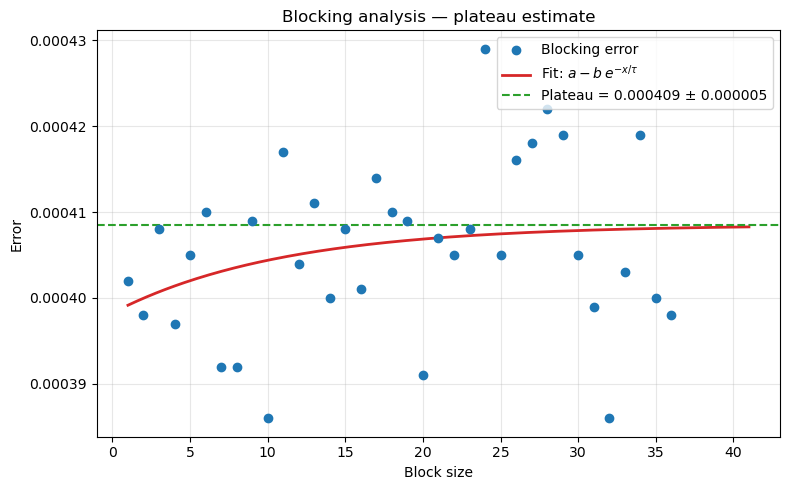

Plateau: 0.000409 ± 0.000005
tau: 11.00


In [19]:
# 2 H2
errors = np.array([
    0.000402, 0.000398, 0.000408, 0.000397, 0.000405,
    0.000410, 0.000392, 0.000392, 0.000409, 0.000386,
    0.000417, 0.000404, 0.000411, 0.000400, 0.000408,
    0.000401, 0.000414, 0.000410, 0.000409, 0.000391,
    0.000407, 0.000405, 0.000408, 0.000429, 0.000405,
    0.000416, 0.000418, 0.000422, 0.000419, 0.000405,
    0.000399, 0.000386, 0.000403, 0.000419, 0.000400,
    0.000398,
])

block_sizes = np.arange(1, len(errors) + 1)

# Fit: error(x) = a - b * exp(-x / tau)
def model(x, a, b, tau):
    return a - b * np.exp(-x / tau)

p0 = [errors[-1], errors[-1] - errors[0], 5.0]
popt, pcov = curve_fit(model, block_sizes, errors, p0=p0, maxfev=10000)
plateau = popt[0]
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(1, block_sizes[-1] + 5, 200)
y_fit = model(x_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(block_sizes, errors, color='C0', zorder=3, label='Blocking error')
ax.plot(x_fit, y_fit, color='C3', lw=2, label=rf'Fit: $a - b\,e^{{-x/\tau}}$')
ax.axhline(plateau, color='C2', ls='--', lw=1.5,
           label=f'Plateau = {plateau:.6f} ± {perr[0]:.6f}')
ax.set_xlabel('Block size')
ax.set_ylabel('Error')
ax.set_title('Blocking analysis — plateau estimate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blocking_plateau.png', dpi=150)
plt.show()

print(f"Plateau: {plateau:.6f} ± {perr[0]:.6f}")
print(f"tau: {popt[2]:.2f}")

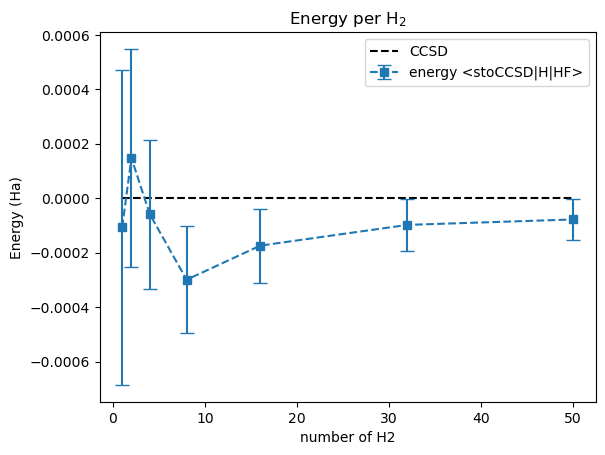

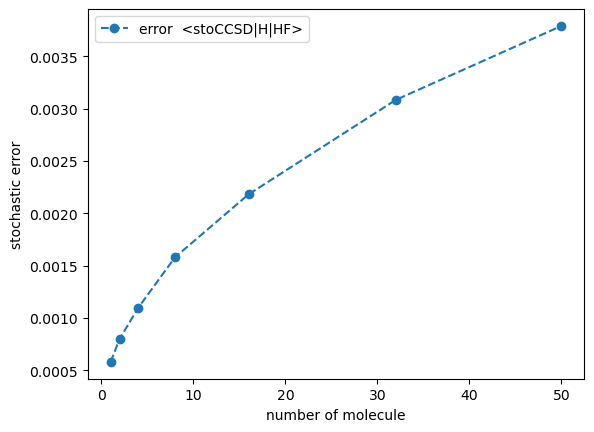

In [6]:
# stocc_1HF
data = '''
# n_mol        E[CCSD]          <stoCCSD|H|HF>              Sign                error_indep
    1       -1.09607128     -1.096178 +/- 0.000579   1.000000 + i 0.000000      0.000572
    2       -2.19214256     -2.191847 +/- 0.000801   1.000000 + i 0.000000      0.000818
    4       -4.38428513     -4.384521 +/- 0.001096   1.000000 + i 0.000000      0.001113
    8       -8.76857026     -8.770965 +/- 0.001579   1.000000 + i 0.000000      0.001581
    16      -17.5371405     -17.539927 +/- 0.002181  1.000000 + i 0.000000      0.002206
    32      -35.0742810     -35.077416 +/- 0.003084  1.000000 + i 0.000000      0.003111
    50      -54.8035641     -54.807465 +/- 0.003791  1.000000 + i 0.000000      0.003880
'''

n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_sign_r = []
qmc_sign_i = []
ind_error = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_sign_r = np.hstack((qmc_sign_r,float(parts[5])/int(parts[0])))
        qmc_sign_i = np.hstack((qmc_sign_i,float(parts[8])/int(parts[0])))
        ind_error = np.hstack((ind_error,float(parts[9])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='energy <stoCCSD|H|HF>')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='error  <stoCCSD|H|HF>')
# plt.plot(n, n*ind_error, 'o--', color='C1', label='indep_error')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

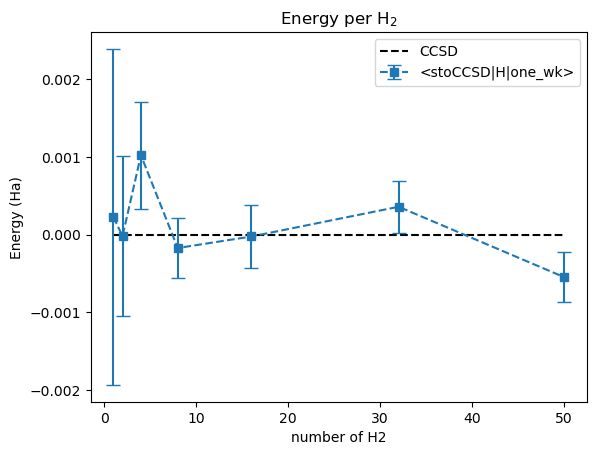

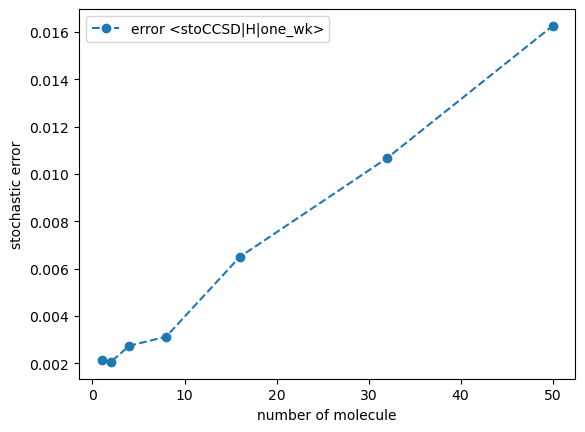

In [7]:
# stocc_1WK
data = '''
# n_mol        E[CCSD]        <stoCCSD|H|one_wk>         Sign                error_indep
    1       -1.09607128     -1.095843 +/- 0.002160   0.999994 + i  0.001469      0.002209
    2       -2.19214256     -2.192179 +/- 0.002065   0.999982 + i  0.002177      0.002058
    4       -4.38428513     -4.380199 +/- 0.002747   0.999968 + i -0.003541      0.002811
    8       -8.76857026     -8.769944 +/- 0.003130   0.999960 + i -0.003464      0.003104
    16      -17.5371405     -17.537515 +/- 0.006497  0.999938 + i -0.000004      0.006497
    32      -35.0742810     -35.062799 +/- 0.010667  0.999901 + i -0.000482      0.010138
    50      -54.8035641     -54.830889 +/- 0.016251  0.999827 + i  0.001663      0.014693
'''

n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_sign_r = []
qmc_sign_i = []
ind_error = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_sign_r = np.hstack((qmc_sign_r,float(parts[5])/int(parts[0])))
        qmc_sign_i = np.hstack((qmc_sign_i,float(parts[8])/int(parts[0])))
        ind_error = np.hstack((ind_error,float(parts[9])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='<stoCCSD|H|one_wk>')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='error <stoCCSD|H|one_wk>')
# plt.plot(n, n*ind_error, 'o--', color='C1', label='indep_error')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

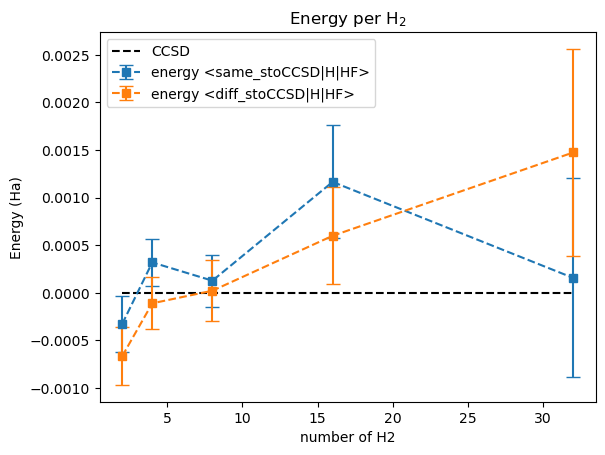

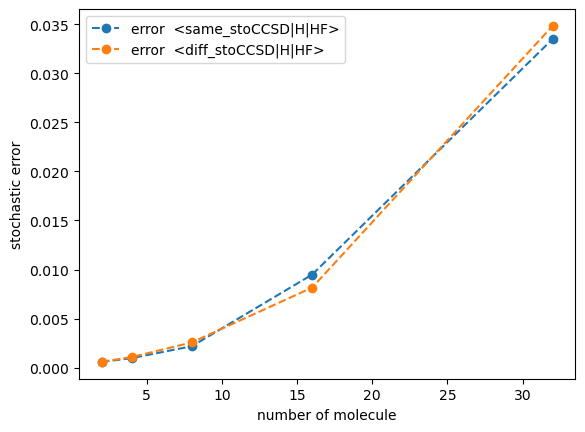

In [3]:
# 10stocc_200walker same stocc for all walkers in at one time step
data = '''
# n_mol        E[CCSD]     <same_stoCCSD|H|walkers>    <diff_stoCCSD|H|walkers>             
    2       -2.19214256     -2.192796 +/- 0.000593      -2.193473 +/- 0.000604
    4       -4.38428513     -4.383007 +/- 0.000981      -4.384725 +/- 0.001086
    8       -8.76857026     -8.767548 +/- 0.002193      -8.768392 +/- 0.002581
    16      -17.5371405     -17.518494 +/- 0.009487     -17.527550 +/- 0.008164
    32      -35.0742810     -35.069244 +/- 0.033480     -35.027100 +/- 0.034817
#    50      -54.8035641    
'''

n = []
ccsd = []
qmc_sto_same = []
qmc_sto_same_err = []
qmc_sto_diff = []
qmc_sto_diff_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto_same = np.hstack((qmc_sto_same,float(parts[2])/int(parts[0])))
        qmc_sto_same_err = np.hstack((qmc_sto_same_err,float(parts[4])/int(parts[0])))
        qmc_sto_diff = np.hstack((qmc_sto_diff,float(parts[5])/int(parts[0])))
        qmc_sto_diff_err = np.hstack((qmc_sto_diff_err,float(parts[7])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto_same-ccsd,yerr=qmc_sto_same_err,fmt='s--', capsize=5, color='C0', label='energy <same_stoCCSD|H|HF>')
plt.errorbar(n,qmc_sto_diff-ccsd,yerr=qmc_sto_diff_err,fmt='s--', capsize=5, color='C1', label='energy <diff_stoCCSD|H|HF>')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_same_err, 'o--', color='C0', label='error  <same_stoCCSD|H|HF>')
plt.plot(n, n*qmc_sto_diff_err, 'o--', color='C1', label='error  <diff_stoCCSD|H|HF>')
# plt.plot(n, n*ind_error, 'o--', color='C1', label='indep_error')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

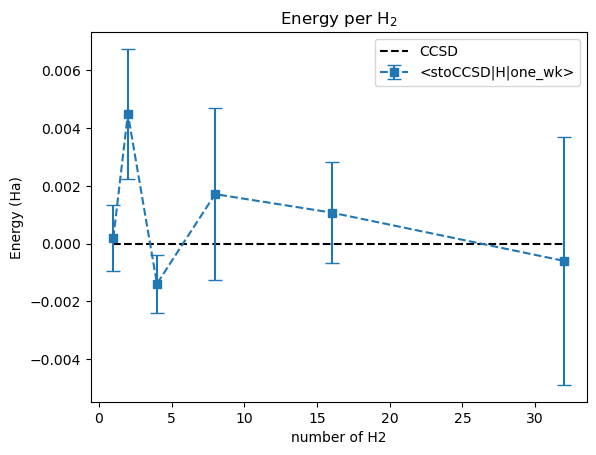

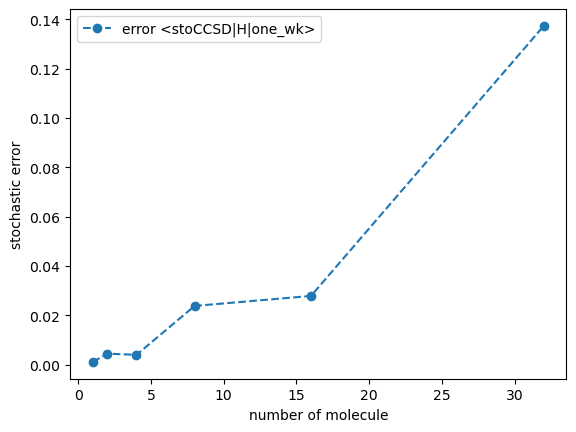

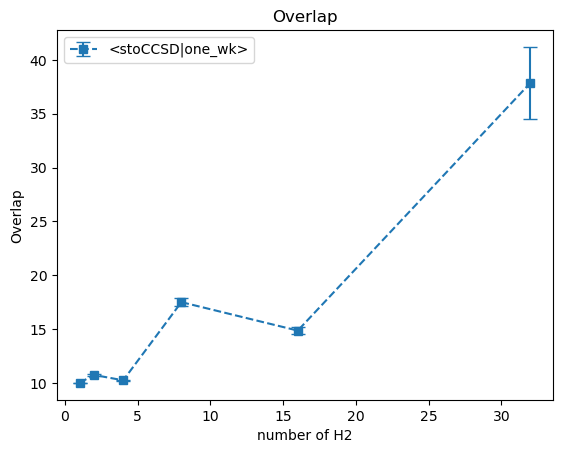

In [7]:
# stocc_1WK overlap
data = '''
# n_mol        E[CCSD]        <stoCCSD|H|one_wk>       <stoCCSD|one_wk>/<HF|one_wk>
    1       -1.09607128     -1.095881 +/- 0.001132      10.025102 +/- 0.012746
    2       -2.19214256     -2.183159 +/- 0.004486      10.750522 +/- 0.073373
    4       -4.38428513     -4.389829 +/- 0.003995      10.254097 +/- 0.052673
    8       -8.76857026     -8.754881 +/- 0.023821      17.511661 +/- 0.379761
    16      -17.5371405     -17.519965 +/- 0.027870     14.869010 +/- 0.324945
    32      -35.0742810     -35.093430 +/- 0.137268     37.868630 +/- 3.332924
#    50      -54.8035641     -54.830889 +/- 0.016251  
'''

n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_olp = []
qmc_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_olp = np.hstack((qmc_olp,float(parts[5])))
        qmc_olp_err = np.hstack((qmc_olp_err,float(parts[7])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='<stoCCSD|H|one_wk>')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='error <stoCCSD|H|one_wk>')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()


# plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_olp,yerr=qmc_olp_err,fmt='s--', capsize=5, color='C0', label='<stoCCSD|one_wk>')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

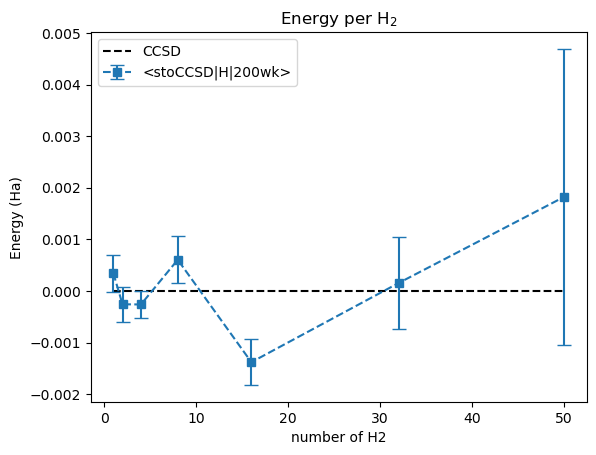

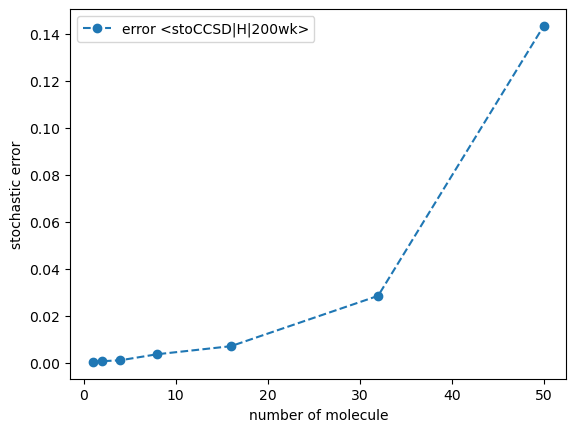

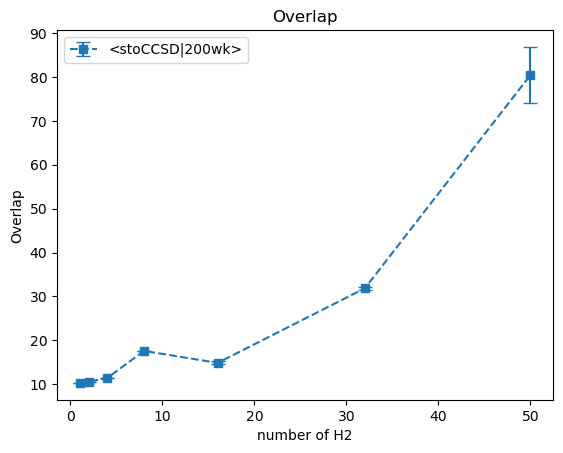

In [ ]:
# 10 stocc_200WK overlap H2
data = '''
# n_mol        E[CCSD]        <stoCCSD|H|one_wk>       <stoCCSD|one_wk>/<HF|one_wk>
    1       -1.09607128     -1.095726 +/- 0.000361      10.317091 +/- 0.005485
    2       -2.19214256     -2.192656 +/- 0.000669      10.616542 +/- 0.008450
    4       -4.38428513     -4.385327 +/- 0.001069      11.416311 +/- 0.013444
    8       -8.76857026     -8.763726 +/- 0.003630      17.606810 +/- 0.070661
    16      -17.5371405     -17.559193 +/- 0.007047     14.869010 +/- 0.324945
    32      -35.0742810     -35.069333 +/- 0.028462     31.860928 +/- 0.372332
    50      -54.8035641     -54.712337 +/- 0.143244     80.447105 +/- 6.384068
'''

n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_olp = []
qmc_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_olp = np.hstack((qmc_olp,float(parts[5])))
        qmc_olp_err = np.hstack((qmc_olp_err,float(parts[7])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='<stoCCSD|H|200wk>')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='error <stoCCSD|H|200wk>')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()


# plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_olp,yerr=qmc_olp_err,fmt='s--', capsize=5, color='C0', label='<stoCCSD|200wk>')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

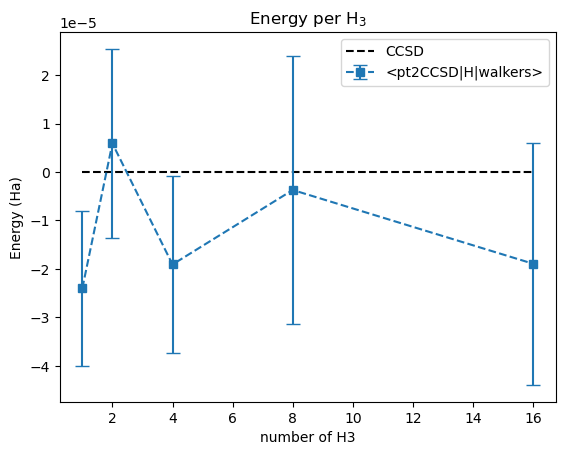

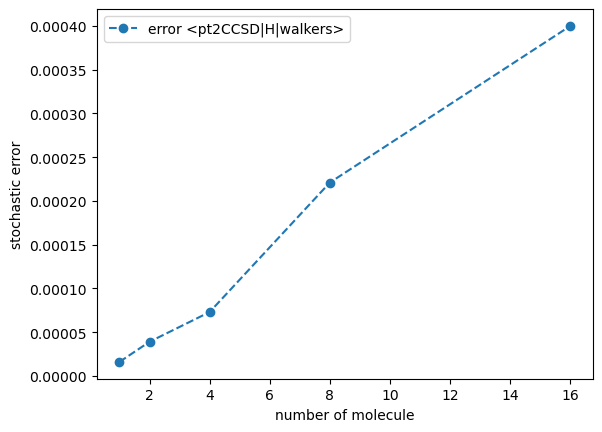

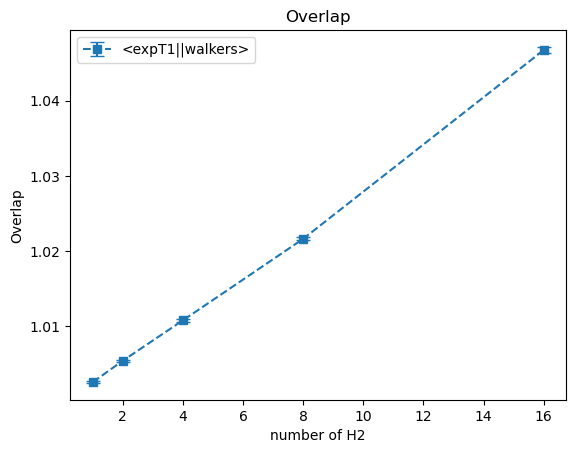

In [6]:
# 10stocc_200WK overlap H3
data = '''
# n_mol        E[CCSD]        <pt2ccsd|H|walks>        <expT1|walkers>
    1       -1.573306     -1.573330 +/- 0.000016      -1.002600 +/- 0.000107
    2       -3.1466128     -3.146601 +/- 0.000039      1.005449 +/- 0.000136
    4       -6.29322568     -6.293302 +/- 0.000073       1.010815 +/- 0.000167
    8       -12.5864513     -12.586481 +/- 0.000221     1.021637 +/- 0.000208
    16      -25.172902     -25.173205 +/- 0.000400    1.046711 +/- 0.000415
#    32    
#    50     
'''

n = []
ccsd = []
qmc_sto = []
qmc_sto_err = []
qmc_olp = []
qmc_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        qmc_sto = np.hstack((qmc_sto,float(parts[2])/int(parts[0])))
        qmc_sto_err = np.hstack((qmc_sto_err,float(parts[4])/int(parts[0])))
        qmc_olp = np.hstack((qmc_olp,float(parts[5])))
        qmc_olp_err = np.hstack((qmc_olp_err,float(parts[7])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,qmc_sto-ccsd,yerr=qmc_sto_err,fmt='s--', capsize=5, color='C0', label='<pt2CCSD|H|walkers>')
plt.xlabel('number of H3')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_3$')
plt.legend()
plt.show()

plt.plot(n, n*qmc_sto_err, 'o--', color='C0', label='error <pt2CCSD|H|walkers>')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()


# plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,np.abs(qmc_olp),yerr=qmc_olp_err,fmt='s--', capsize=5, color='C0', label='<expT1||walkers>')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()